# Experiment 8.1.1 — Two-layer multi-threshold factorial

Analysis-only notebook. It compares the 2×2 L1/L2 Binary-vs-MT3 factorial under the locked Exp7.3 A2 training contract. No training is performed here.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_8_1_1_two_layer_mt_factorial' / 'two_layer_mt_factorial_v1'

manifest = json.loads((ART / 'manifest.json').read_text())
runs = pd.read_csv(ART / 'method_runs.csv')
summary = pd.read_csv(ART / 'method_summary.csv')
contrasts = pd.read_csv(ART / 'contrast_summary.csv')
effects = pd.read_csv(ART / 'factorial_effect_summary.csv')
activity = pd.read_csv(ART / 'activity_summary.csv')
manifest


{'architecture': {'l1_shifts': [2, 3, 4],
  'l1_width': 128,
  'l2_shifts': [2, 3, 4],
  'l2_width': 128,
  'threshold': 0.5,
  'threshold_multipliers': [0.5, 1.0, 1.5]},
 'counts': {'methods': 4, 'parallel_runs': 12, 'seeds': 3},
 'diagnostics': {'aggregations': ['whole_mean', 'fixed250_ordered_mean'],
  'factorial_effects': ['l1_mt_main_effect',
   'l2_mt_main_effect',
   'l1_x_l2_interaction'],
  'states': ['pre_reset', 'communication']},
 'experiment_id': 'experiment_8_1_1_two_layer_mt_factorial',
 'method_order': ['bb', 'mb', 'bm', 'mm'],
 'methods': {'bb': {'l1_coding': 'binary', 'l2_coding': 'binary'},
  'bm': {'l1_coding': 'binary', 'l2_coding': 'hetero3'},
  'mb': {'l1_coding': 'hetero3', 'l2_coding': 'binary'},
  'mm': {'l1_coding': 'hetero3', 'l2_coding': 'hetero3'}},
 'primary_representation_metric': 'l2_communication_fixed250_ba',
 'protocol_version': 'two_layer_mt_factorial_v1',
 'scope': '2x2 factorial over L1/L2 binary vs fixed heterogeneous-threshold coding',
 'seconda

## Method-level local representation

The primary endpoint is L2 communicated Fixed250 probe BA. Native Linear/WCCE test BA remains secondary.


In [2]:
cols = [
    'method',
    'linear_test_ba_mean',
    'l1_pre_reset_fixed250_ba_mean',
    'l1_communication_fixed250_ba_mean',
    'l2_pre_reset_fixed250_ba_mean',
    'l2_communication_fixed250_ba_mean',
    'l1_threshold_delta_fixed250_mean',
    'l1_to_l2_transform_delta_fixed250_mean',
    'l2_threshold_delta_fixed250_mean',
]
summary[[c for c in cols if c in summary.columns]]


,method,linear_test_ba_mean,l1_pre_reset_fixed250_ba_mean,l1_communication_fixed250_ba_mean,l2_pre_reset_fixed250_ba_mean,l2_communication_fixed250_ba_mean,l1_threshold_delta_fixed250_mean,l1_to_l2_transform_delta_fixed250_mean,l2_threshold_delta_fixed250_mean
0,bb,0.564502,0.623111,0.534067,0.589742,0.618353,-0.089044,0.055675,0.028611
1,mb,0.534664,0.624587,0.567509,0.580566,0.593620,-0.057077,0.013057,0.013054
2,bm,0.560663,0.614439,0.560389,0.591860,0.601601,-0.054050,0.031471,0.009741
3,mm,0.564206,0.624429,0.572734,0.575604,0.638428,-0.051696,0.002871,0.062824


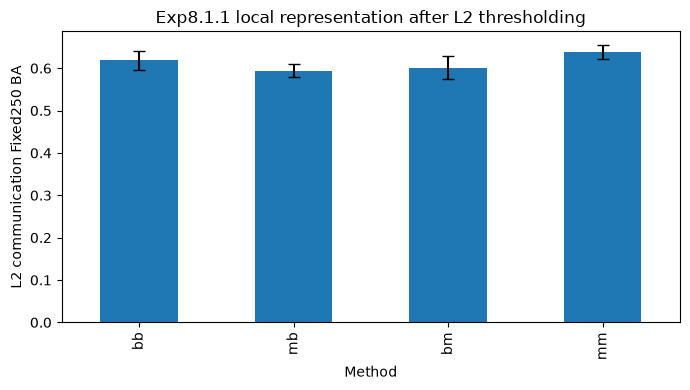

In [3]:
order = manifest['method_order']
plot_df = runs.groupby('method', sort=False)['l2_communication_fixed250_ba'].agg(['mean', 'std']).reindex(order)
ax = plot_df['mean'].plot(kind='bar', yerr=plot_df['std'], capsize=4, figsize=(7, 4))
ax.set_ylabel('L2 communication Fixed250 BA')
ax.set_xlabel('Method')
ax.set_title('Exp8.1.1 local representation after L2 thresholding')
plt.tight_layout()
plt.show()


## Information-flow view

Compare L1 pre-reset → L1 communication → L2 pre-reset → L2 communication for each factorial cell.


In [4]:
flow_cols = [
    'l1_pre_reset_fixed250_ba',
    'l1_communication_fixed250_ba',
    'l2_pre_reset_fixed250_ba',
    'l2_communication_fixed250_ba',
]
flow = runs.groupby('method', sort=False)[flow_cols].mean().reindex(manifest['method_order'])
flow


,l1_pre_reset_fixed250_ba,l1_communication_fixed250_ba,l2_pre_reset_fixed250_ba,l2_communication_fixed250_ba
method,,,,
bb,0.623111,0.534067,0.589742,0.618353
mb,0.624587,0.567509,0.580566,0.593620
bm,0.614439,0.560389,0.591860,0.601601
mm,0.624429,0.572734,0.575604,0.638428


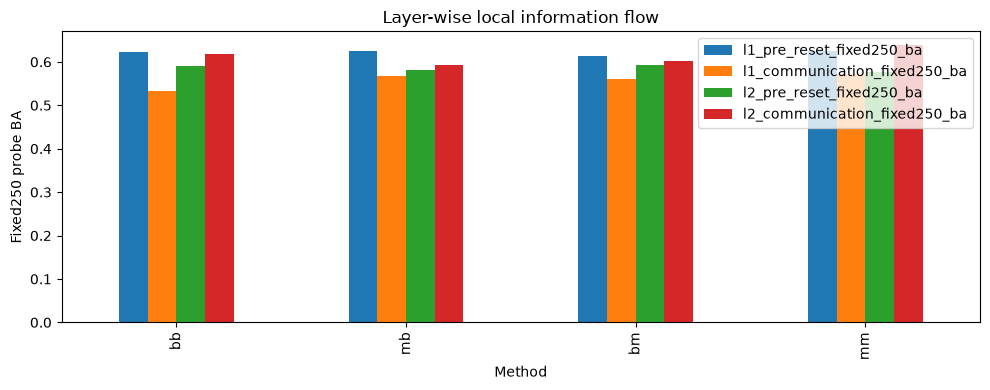

In [5]:
ax = flow.plot(kind='bar', figsize=(10, 4))
ax.set_ylabel('Fixed250 probe BA')
ax.set_xlabel('Method')
ax.set_title('Layer-wise local information flow')
plt.tight_layout()
plt.show()


## Seed-paired contrasts

`MM - MB` is the direct test of whether changing only L2 from Binary to MT3 preserves an MT-L1 representation. `BM - BB` tests the same L2 change when L1 remains Binary.


In [6]:
contrast_cols = [
    c for c in contrasts.columns
    if c in {'contrast', 'method_a', 'method_b'}
    or c.startswith('delta_l2_communication_fixed250_ba')
    or c.startswith('delta_l2_pre_reset_fixed250_ba')
    or c.startswith('delta_linear_test_ba')
]
contrasts[contrast_cols]


,contrast,method_a,method_b,delta_linear_test_ba_mean,delta_linear_test_ba_std,delta_l2_pre_reset_fixed250_ba_mean,delta_l2_pre_reset_fixed250_ba_std,delta_l2_communication_fixed250_ba_mean,delta_l2_communication_fixed250_ba_std
0,l1_mt_when_l2_binary,mb,bb,-0.029838,0.042957,-0.009176,0.015189,-0.024733,0.012031
1,l2_mt_when_l1_binary,bm,bb,-0.003839,0.005965,0.002118,0.047591,-0.016752,0.031578
2,l2_mt_when_l1_mt,mm,mb,0.029542,0.024095,-0.004962,0.011267,0.044808,0.014632
3,l1_mt_when_l2_mt,mm,bm,0.003543,0.024424,-0.016256,0.021422,0.036827,0.034555
4,mm_vs_bb,mm,bb,-0.000296,0.021157,-0.014138,0.026454,0.020075,0.009776


## 2×2 factorial effects

The interaction is `MM - MB - BM + BB`. A positive interaction on L2 communicated Fixed250 BA means L2 MT is especially useful when L1 is already MT.


In [7]:
effects[effects['metric'].isin([
    'l2_communication_fixed250_ba',
    'l2_pre_reset_fixed250_ba',
    'linear_test_ba',
])].reset_index(drop=True)


,metric,effect,mean,std
0,linear_test_ba,l1_mt_main_effect,-0.013147,0.032470
1,linear_test_ba,l2_mt_main_effect,0.012852,0.011895
2,linear_test_ba,l1_x_l2_interaction,0.033381,0.025813
3,l2_pre_reset_fixed250_ba,l1_mt_main_effect,-0.012716,0.003747
4,l2_pre_reset_fixed250_ba,l2_mt_main_effect,-0.001422,0.029413
5,l2_pre_reset_fixed250_ba,l1_x_l2_interaction,-0.007080,0.036374
6,l2_communication_fixed250_ba,l1_mt_main_effect,0.006047,0.012590
7,l2_communication_fixed250_ba,l2_mt_main_effect,0.014028,0.009734
8,l2_communication_fixed250_ba,l1_x_l2_interaction,0.061559,0.045205


## Threshold × tau activity

Inspect L2 MT activity for saturation of the 0.5× threshold bank before interpreting a negative MT result.


In [8]:
activity_cols = [
    'method', 'layer', 'threshold_multiplier', 'shift',
    'mean_value_per_neuron_step_mean', 'fraction_nonzero_mean',
]
activity[[c for c in activity_cols if c in activity.columns]].sort_values(
    ['method', 'layer', 'threshold_multiplier', 'shift']
).reset_index(drop=True)


,method,layer,threshold_multiplier,shift,mean_value_per_neuron_step_mean,fraction_nonzero_mean
0,bb,l1,1.0,2,0.007565,0.007565
1,bb,l1,1.0,3,0.027848,0.027848
2,bb,l1,1.0,4,0.132345,0.132345
3,bb,l2,1.0,2,0.348633,0.348633
4,bb,l2,1.0,3,0.365308,0.365308
5,bb,l2,1.0,4,0.380766,0.380766
6,bm,l1,1.0,2,0.007888,0.007888
7,bm,l1,1.0,3,0.030503,0.030503
8,bm,l1,1.0,4,0.132053,0.132053
9,bm,l2,0.5,2,0.403812,0.403812
